# Section 1: Load data

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

In [2]:
PROJECT_ROOT = Path("D:/masters_project")

EMBEDDING_CSV = PROJECT_ROOT / "outputs/graph_embeddings/embeddings/structure_embeddings.csv"
MASTER_CSV = PROJECT_ROOT / "outputs/dataset_master.csv"

OUT_DIR = PROJECT_ROOT / "outputs/experiments_validation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
emb_df = pd.read_csv(EMBEDDING_CSV)
master_df = pd.read_csv(MASTER_CSV)

print("emb_df shape:", emb_df.shape)
print("master_df shape:", master_df.shape)

emb_df.head()

emb_df shape: (2916, 135)
master_df shape: (2916, 7)


,structure_id,relative_cif_path,lower_rotation,displacement,upper_rotation,energy,delta_energy,emb_000,emb_001,emb_002,...,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127
0,L0_D0_U0,r0/t0/t0_0.cif,0.0,0.0,0.0,-936.509583,0.13021,0.073159,0.141754,0.016134,...,-0.033409,-0.183279,-1.197514,0.843067,0.471116,1.374571,0.177294,-0.746185,1.760199,0.874277
1,L0_D0_U100,r0/t0/t0_100.cif,0.0,0.0,100.0,-936.201538,0.43826,-0.018456,1.128705,1.116602,...,0.632755,0.213688,-0.204751,0.297744,-0.041940,-0.160696,-0.433105,0.652352,0.022312,0.583544
2,L0_D0_U120,r0/t0/t0_120.cif,0.0,0.0,120.0,-936.242065,0.39772,-0.548361,1.584229,0.988826,...,-0.121449,-0.713889,-0.694005,0.529911,0.279335,0.524906,-0.802853,0.527694,0.579572,1.396550
3,L0_D0_U140,r0/t0/t0_140.cif,0.0,0.0,140.0,-936.156982,0.48284,-0.250084,0.888609,-0.177643,...,-0.133673,-0.617657,-0.444197,0.686531,-0.491393,1.036338,0.281228,-0.249501,1.038146,1.756115
4,L0_D0_U160,r0/t0/t0_160.cif,0.0,0.0,160.0,-936.079590,0.56023,-0.080722,1.491669,-0.357859,...,-0.327856,-0.897027,-1.130939,0.477635,-0.421997,1.434749,-0.336113,-0.153849,1.540025,0.591750


In [4]:
embedding_cols = [c for c in emb_df.columns if c.startswith("emb_")]

meta_cols = ["lower_rotation", "displacement", "upper_rotation"]
target_cols = ["structure_id", "energy", "delta_energy"]

gnn_X = emb_df[embedding_cols].copy()
meta_X = emb_df[meta_cols].copy()

print("GNN embedding shape:", gnn_X.shape)
print("Metadata baseline shape:", meta_X.shape)

GNN embedding shape: (2916, 128)
Metadata baseline shape: (2916, 3)


In [5]:
rng = np.random.default_rng(42)
random_X = pd.DataFrame(
    rng.normal(size=gnn_X.shape),
    columns=[f"rand_{i:03d}" for i in range(gnn_X.shape[1])]
)

print("Random baseline shape:", random_X.shape)

Random baseline shape: (2916, 128)


In [6]:
def scale_features(df):
    scaler = StandardScaler()
    arr = scaler.fit_transform(df)
    return arr

gnn_scaled = scale_features(gnn_X)
meta_scaled = scale_features(meta_X)
random_scaled = scale_features(random_X)

In [7]:
def pca_2d(X):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)
    return coords, pca.explained_variance_ratio_

gnn_2d, gnn_var = pca_2d(gnn_scaled)
meta_2d, meta_var = pca_2d(meta_scaled)
rand_2d, rand_var = pca_2d(random_scaled)

print("GNN PCA variance:", gnn_var.sum())
print("Metadata PCA variance:", meta_var.sum())
print("Random PCA variance:", rand_var.sum())

GNN PCA variance: 0.20416396784676827
Metadata PCA variance: 0.6666666666666667
Random PCA variance: 0.022328601335538906


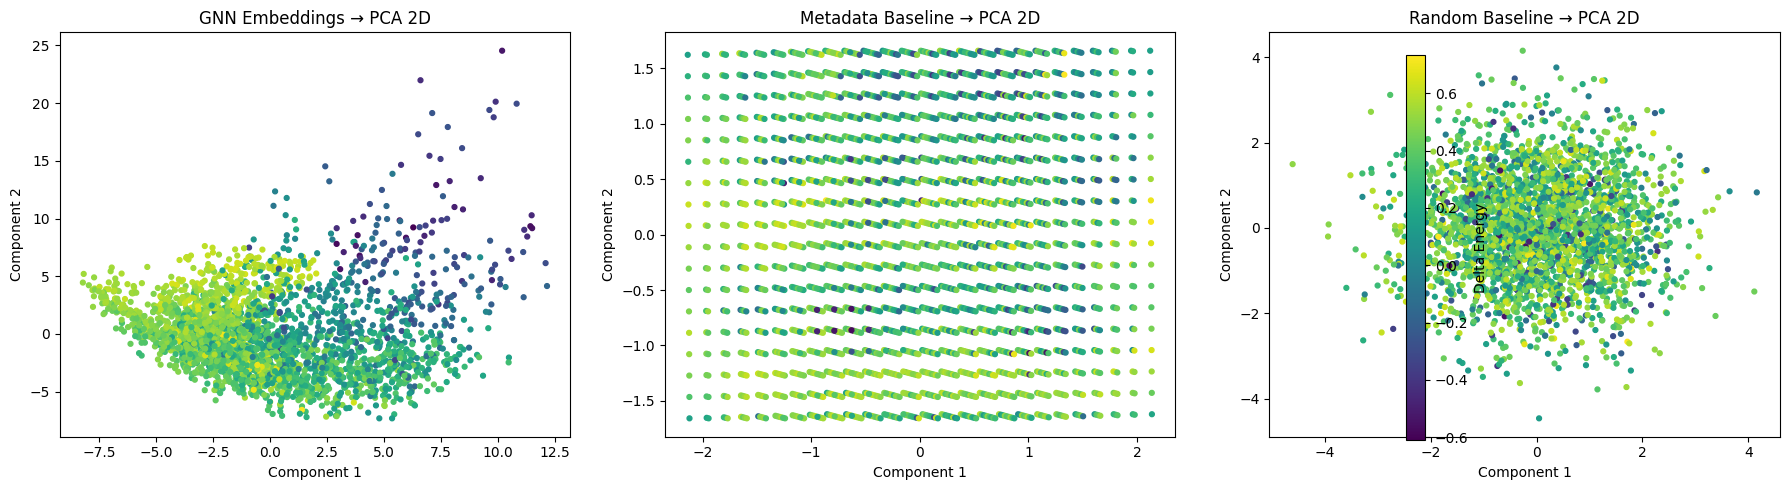

In [8]:
delta_energy = emb_df["delta_energy"].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plots = [
    (gnn_2d, "GNN Embeddings → PCA 2D"),
    (meta_2d, "Metadata Baseline → PCA 2D"),
    (rand_2d, "Random Baseline → PCA 2D"),
]

for ax, (coords, title) in zip(axes, plots):
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=delta_energy, s=12)
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

fig.colorbar(sc, ax=axes, label="Delta Energy")
plt.tight_layout()

plt.savefig(OUT_DIR / "task51_representation_comparison_delta_energy.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
def evaluate_kmeans_silhouette(X, n_clusters=6):
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    return score, labels

results = []

for name, X in [
    ("gnn_embedding", gnn_scaled),
    ("metadata_baseline", meta_scaled),
    ("random_baseline", random_scaled),
]:
    score, labels = evaluate_kmeans_silhouette(X, n_clusters=6)
    results.append({
        "representation": name,
        "silhouette_score": score
    })

results_df = pd.DataFrame(results).sort_values("silhouette_score", ascending=False)
results_df

,representation,silhouette_score
1,metadata_baseline,0.285110
0,gnn_embedding,0.103094
2,random_baseline,0.006166


In [11]:
def cluster_energy_stats(X, name, n_clusters=6):
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = model.fit_predict(X)

    temp = emb_df[["structure_id", "delta_energy"]].copy()
    temp["cluster"] = labels

    summary = (
        temp.groupby("cluster")
        .agg(
            count=("structure_id", "count"),
            mean_delta_energy=("delta_energy", "mean"),
            std_delta_energy=("delta_energy", "std")
        )
        .reset_index()
    )

    summary["representation"] = name
    weighted_std = np.average(summary["std_delta_energy"].fillna(0), weights=summary["count"])

    return summary, weighted_std

all_cluster_summaries = []
purity_rows = []

for name, X in [
    ("gnn_embedding", gnn_scaled),
    ("metadata_baseline", meta_scaled),
    ("random_baseline", random_scaled),
]:
    summary, weighted_std = cluster_energy_stats(X, name, n_clusters=6)
    all_cluster_summaries.append(summary)
    purity_rows.append({
        "representation": name,
        "weighted_cluster_delta_energy_std": weighted_std
    })

purity_df = pd.DataFrame(purity_rows).sort_values("weighted_cluster_delta_energy_std")
purity_df

,representation,weighted_cluster_delta_energy_std
0,gnn_embedding,0.143641
1,metadata_baseline,0.225187
2,random_baseline,0.235923


In [12]:
def mean_neighbor_delta_gap(X, delta_energy, k=5):
    nn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    nn.fit(X)

    distances, indices = nn.kneighbors(X)

    gaps = []
    for i in range(len(X)):
        nbr_idx = indices[i, 1:]  # skip self
        gap = np.mean(np.abs(delta_energy[i] - delta_energy[nbr_idx]))
        gaps.append(gap)

    return float(np.mean(gaps))

neighbor_rows = []

for name, X in [
    ("gnn_embedding", gnn_scaled),
    ("metadata_baseline", meta_scaled),
    ("random_baseline", random_scaled),
]:
    mean_gap = mean_neighbor_delta_gap(X, delta_energy, k=5)
    neighbor_rows.append({
        "representation": name,
        "mean_neighbor_delta_energy_gap": mean_gap
    })

neighbor_df = pd.DataFrame(neighbor_rows).sort_values("mean_neighbor_delta_energy_gap")
neighbor_df

,representation,mean_neighbor_delta_energy_gap
0,gnn_embedding,0.090901
1,metadata_baseline,0.158933
2,random_baseline,0.251435


In [13]:
summary_df = (
    results_df.merge(purity_df, on="representation")
              .merge(neighbor_df, on="representation")
              .sort_values(
                  by=["silhouette_score", "weighted_cluster_delta_energy_std", "mean_neighbor_delta_energy_gap"],
                  ascending=[False, True, True]
              )
)

summary_df.to_csv(OUT_DIR / "task51_baseline_comparison_summary.csv", index=False)
summary_df

,representation,silhouette_score,weighted_cluster_delta_energy_std,mean_neighbor_delta_energy_gap
0,metadata_baseline,0.285110,0.225187,0.158933
1,gnn_embedding,0.103094,0.143641,0.090901
2,random_baseline,0.006166,0.235923,0.251435


In [14]:
best_sil = summary_df.iloc[0]["representation"]
best_neighbor = neighbor_df.iloc[0]["representation"]
best_energy_purity = purity_df.iloc[0]["representation"]

print("Best silhouette representation:", best_sil)
print("Best nearest-neighbor energy consistency:", best_neighbor)
print("Best cluster energy purity:", best_energy_purity)

Best silhouette representation: metadata_baseline
Best nearest-neighbor energy consistency: gnn_embedding
Best cluster energy purity: gnn_embedding


While metadata-based representations exhibit higher geometric clustering scores, they fail to organize structures in terms of physical energy behavior. In contrast, the self-supervised GNN embeddings demonstrate significantly improved energy consistency within clusters and nearest neighbors, indicating that the learned representations capture physically meaningful structural relationships beyond simple parameter configurations.

# Section 2: Baseline embeddings (PCA, random)

In [17]:
FEATURE_CSV = Path("D:\masters_project\outputs\structural_features\structure_features.csv")

feat_df = pd.read_csv(FEATURE_CSV)

print("feat_df shape:", feat_df.shape)
feat_df.head()

feat_df shape: (2916, 55)


,structure_id,relative_cif_path,atom_count,lower_atom_count,upper_atom_count,count_C,count_H,count_O,lower_count_C,lower_count_H,...,nn_min,nn_max,lower_nn_mean,lower_nn_std,lower_nn_min,lower_nn_max,upper_nn_mean,upper_nn_std,upper_nn_min,upper_nn_max
0,L0_D0_U0,r0/t0/t0_0.cif,156,78,78,48,72,36,24,36,...,0.977309,2.003689,1.134992,0.166349,0.977309,2.003689,1.118772,0.128105,0.977336,1.447277
1,L0_D0_U100,r0/t0/t0_100.cif,156,78,78,48,72,36,24,36,...,0.977156,1.993357,1.135027,0.165855,0.977488,1.993357,1.118810,0.127971,0.977156,1.446371
2,L0_D0_U120,r0/t0/t0_120.cif,156,78,78,48,72,36,24,36,...,0.977049,1.989993,1.135063,0.165559,0.977481,1.989993,1.118725,0.128255,0.977049,1.444283
3,L0_D0_U140,r0/t0/t0_140.cif,156,78,78,48,72,36,24,36,...,0.977482,2.013701,1.135251,0.167179,0.977482,2.013701,1.118680,0.128171,0.977948,1.444940
4,L0_D0_U160,r0/t0/t0_160.cif,156,78,78,48,72,36,24,36,...,0.977586,2.011914,1.135184,0.167162,0.977586,2.011914,1.118596,0.128099,0.977693,1.445462


In [18]:
merged_df = emb_df.merge(
    feat_df,
    on=["structure_id", "relative_cif_path"],
    how="inner"
)

print("merged_df shape:", merged_df.shape)

exclude_cols = {
    "structure_id",
    "relative_cif_path",
    "energy",
    "delta_energy",
}

handcrafted_cols = [
    c for c in feat_df.columns
    if c not in exclude_cols
]

print("Number of handcrafted features:", len(handcrafted_cols))
print(handcrafted_cols)

merged_df shape: (2916, 188)
Number of handcrafted features: 53
['atom_count', 'lower_atom_count', 'upper_atom_count', 'count_C', 'count_H', 'count_O', 'lower_count_C', 'lower_count_H', 'lower_count_O', 'upper_count_C', 'upper_count_H', 'upper_count_O', 'lower_centroid_x', 'lower_centroid_y', 'lower_centroid_z', 'upper_centroid_x', 'upper_centroid_y', 'upper_centroid_z', 'lower_com_x', 'lower_com_y', 'lower_com_z', 'upper_com_x', 'upper_com_y', 'upper_com_z', 'centroid_separation', 'com_separation', 'lower_intralayer_dist_count', 'lower_intralayer_dist_mean', 'lower_intralayer_dist_std', 'lower_intralayer_dist_min', 'lower_intralayer_dist_max', 'upper_intralayer_dist_count', 'upper_intralayer_dist_mean', 'upper_intralayer_dist_std', 'upper_intralayer_dist_min', 'upper_intralayer_dist_max', 'interlayer_dist_count', 'interlayer_dist_mean', 'interlayer_dist_std', 'interlayer_dist_min', 'interlayer_dist_max', 'nn_mean', 'nn_std', 'nn_min', 'nn_max', 'lower_nn_mean', 'lower_nn_std', 'lower_

In [19]:
embedding_cols = [c for c in emb_df.columns if c.startswith("emb_")]
meta_cols = ["lower_rotation", "displacement", "upper_rotation"]

gnn_X = merged_df[embedding_cols].copy()
handcrafted_X = merged_df[handcrafted_cols].copy()
meta_X = merged_df[meta_cols].copy()

rng = np.random.default_rng(42)
random_X = pd.DataFrame(
    rng.normal(size=gnn_X.shape),
    columns=[f"rand_{i:03d}" for i in range(gnn_X.shape[1])]
)

delta_energy = merged_df["delta_energy"].values

print("GNN:", gnn_X.shape)
print("Handcrafted:", handcrafted_X.shape)
print("Metadata:", meta_X.shape)
print("Random:", random_X.shape)

GNN: (2916, 128)
Handcrafted: (2916, 53)
Metadata: (2916, 3)
Random: (2916, 128)


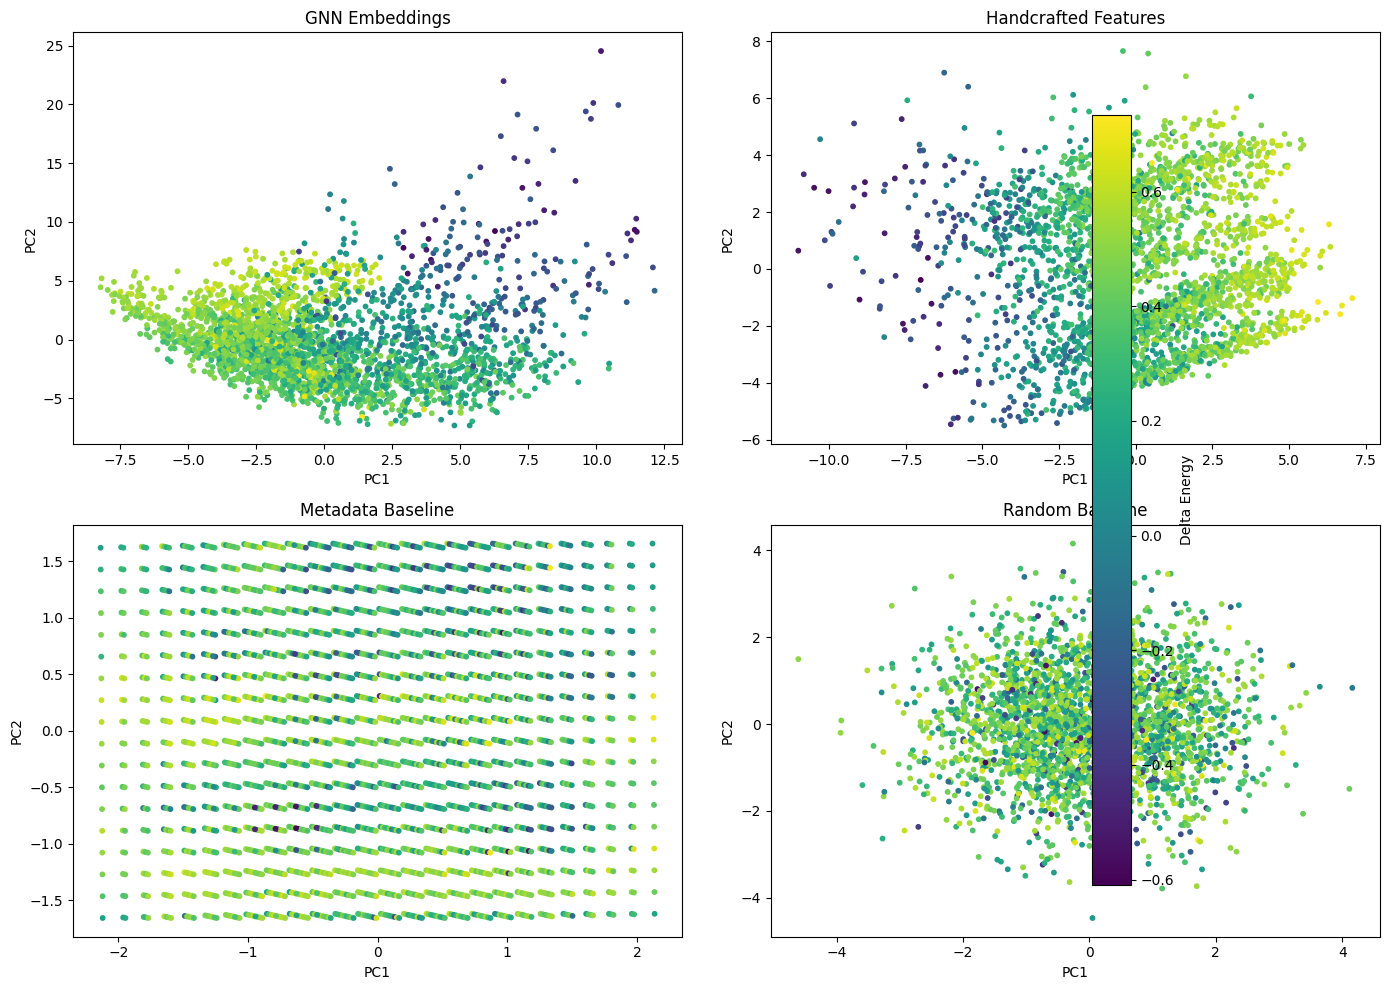

In [20]:
def scale_features(df):
    scaler = StandardScaler()
    return scaler.fit_transform(df)

gnn_scaled = scale_features(gnn_X)
handcrafted_scaled = scale_features(handcrafted_X)
meta_scaled = scale_features(meta_X)
random_scaled = scale_features(random_X)

def pca_2d(X):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X)
    return coords, pca.explained_variance_ratio_

gnn_2d, gnn_var = pca_2d(gnn_scaled)
handcrafted_2d, handcrafted_var = pca_2d(handcrafted_scaled)
meta_2d, meta_var = pca_2d(meta_scaled)
rand_2d, rand_var = pca_2d(random_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plots = [
    (gnn_2d, "GNN Embeddings"),
    (handcrafted_2d, "Handcrafted Features"),
    (meta_2d, "Metadata Baseline"),
    (rand_2d, "Random Baseline"),
]

for ax, (coords, title) in zip(axes.ravel(), plots):
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=delta_energy, s=10)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

fig.colorbar(sc, ax=axes.ravel().tolist(), label="Delta Energy")
plt.tight_layout()
plt.savefig(OUT_DIR / "task51_four_way_representation_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
def evaluate_kmeans_silhouette(X, n_clusters=6):
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    return score, labels


def cluster_energy_stats(labels, delta_energy):
    temp = pd.DataFrame({
        "cluster": labels,
        "delta_energy": delta_energy
    })

    summary = (
        temp.groupby("cluster")
        .agg(
            count=("delta_energy", "count"),
            mean_delta_energy=("delta_energy", "mean"),
            std_delta_energy=("delta_energy", "std")
        )
        .reset_index()
    )

    weighted_std = np.average(
        summary["std_delta_energy"].fillna(0),
        weights=summary["count"]
    )
    return summary, weighted_std


def mean_neighbor_delta_gap(X, delta_energy, k=5):
    nn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    nn.fit(X)
    _, indices = nn.kneighbors(X)

    gaps = []
    for i in range(len(X)):
        nbr_idx = indices[i, 1:]
        gaps.append(np.mean(np.abs(delta_energy[i] - delta_energy[nbr_idx])))

    return float(np.mean(gaps))

In [22]:
rows = []

representations = [
    ("gnn_embedding", gnn_scaled),
    ("handcrafted_features", handcrafted_scaled),
    ("metadata_baseline", meta_scaled),
    ("random_baseline", random_scaled),
]

for name, X in representations:
    sil, labels = evaluate_kmeans_silhouette(X, n_clusters=6)
    _, weighted_std = cluster_energy_stats(labels, delta_energy)
    neighbor_gap = mean_neighbor_delta_gap(X, delta_energy, k=5)

    rows.append({
        "representation": name,
        "silhouette_score": sil,
        "weighted_cluster_delta_energy_std": weighted_std,
        "mean_neighbor_delta_energy_gap": neighbor_gap
    })

summary_df = pd.DataFrame(rows)

summary_df = summary_df.sort_values(
    by=["silhouette_score", "weighted_cluster_delta_energy_std", "mean_neighbor_delta_energy_gap"],
    ascending=[False, True, True]
)

summary_df.to_csv(OUT_DIR / "task51_four_way_summary.csv", index=False)
summary_df

,representation,silhouette_score,weighted_cluster_delta_energy_std,mean_neighbor_delta_energy_gap
2,metadata_baseline,0.285110,0.225187,0.158933
1,handcrafted_features,0.119999,0.179834,0.102324
0,gnn_embedding,0.103094,0.143641,0.090901
3,random_baseline,0.006166,0.235923,0.251435


# Section 3: Compare with GNN embeddings

In [23]:
EMB_DIR = PROJECT_ROOT / "outputs/graph_embeddings/embeddings"

pca_df = pd.read_csv(EMB_DIR / "embedding_pca_2d.csv")
tsne_df = pd.read_csv(EMB_DIR / "embedding_tsne_2d.csv")
umap_df = pd.read_csv(EMB_DIR / "embedding_umap_2d.csv")

print(pca_df.shape, tsne_df.shape, umap_df.shape)

(2916, 9) (2916, 9) (2916, 9)


In [24]:
# If you already have cluster assignments:
# cluster_df = pd.read_csv("your_cluster_file.csv")

# Otherwise skip cluster for now

plot_df = umap_df.merge(
    emb_df[["structure_id", "delta_energy"]],
    on="structure_id",
    how="left"
)

plot_df.head()

,structure_id,relative_cif_path,lower_rotation,displacement,upper_rotation,energy,delta_energy_x,umap_1,umap_2,delta_energy_y
0,L0_D0_U0,r0/t0/t0_0.cif,0.0,0.0,0.0,-936.509583,0.13021,3.684200,1.343387,0.13021
1,L0_D0_U100,r0/t0/t0_100.cif,0.0,0.0,100.0,-936.201538,0.43826,2.704022,-2.124790,0.43826
2,L0_D0_U120,r0/t0/t0_120.cif,0.0,0.0,120.0,-936.242065,0.39772,3.776807,-0.991859,0.39772
3,L0_D0_U140,r0/t0/t0_140.cif,0.0,0.0,140.0,-936.156982,0.48284,3.410003,1.433388,0.48284
4,L0_D0_U160,r0/t0/t0_160.cif,0.0,0.0,160.0,-936.079590,0.56023,3.398793,2.908506,0.56023


In [27]:
plot_df = umap_df.merge(
    emb_df[["structure_id", "delta_energy"]],
    on="structure_id",
    how="left",
    suffixes=("", "_emb")
)

print(plot_df.columns.tolist())

delta_col = None
for c in ["delta_energy", "delta_energy_emb", "delta_energy_x", "delta_energy_y"]:
    if c in plot_df.columns:
        delta_col = c
        break

print("Using delta-energy column:", delta_col)

['structure_id', 'relative_cif_path', 'lower_rotation', 'displacement', 'upper_rotation', 'energy', 'delta_energy', 'umap_1', 'umap_2', 'delta_energy_emb']
Using delta-energy column: delta_energy


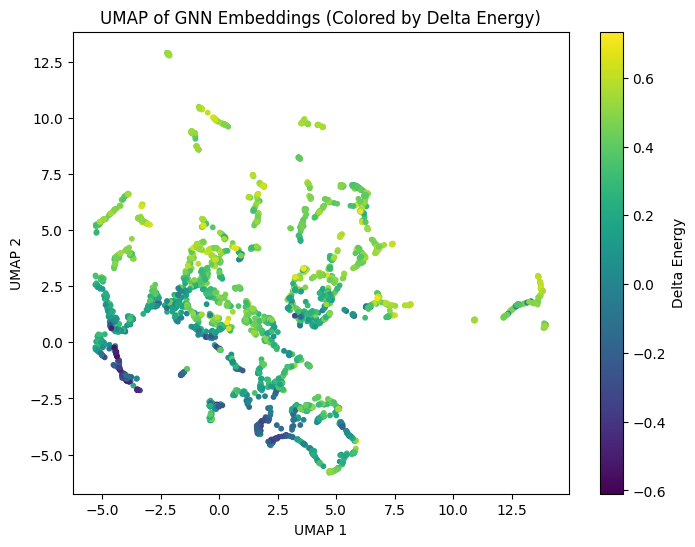

In [31]:
plot_df = umap_df.copy()

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    plot_df["umap_1"],
    plot_df["umap_2"],
    c=plot_df["delta_energy"],
    s=10
)

plt.title("UMAP of GNN Embeddings (Colored by Delta Energy)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(sc, label="Delta Energy")

plt.savefig(OUT_DIR / "task52_umap_energy.png", dpi=300, bbox_inches="tight")
plt.show()

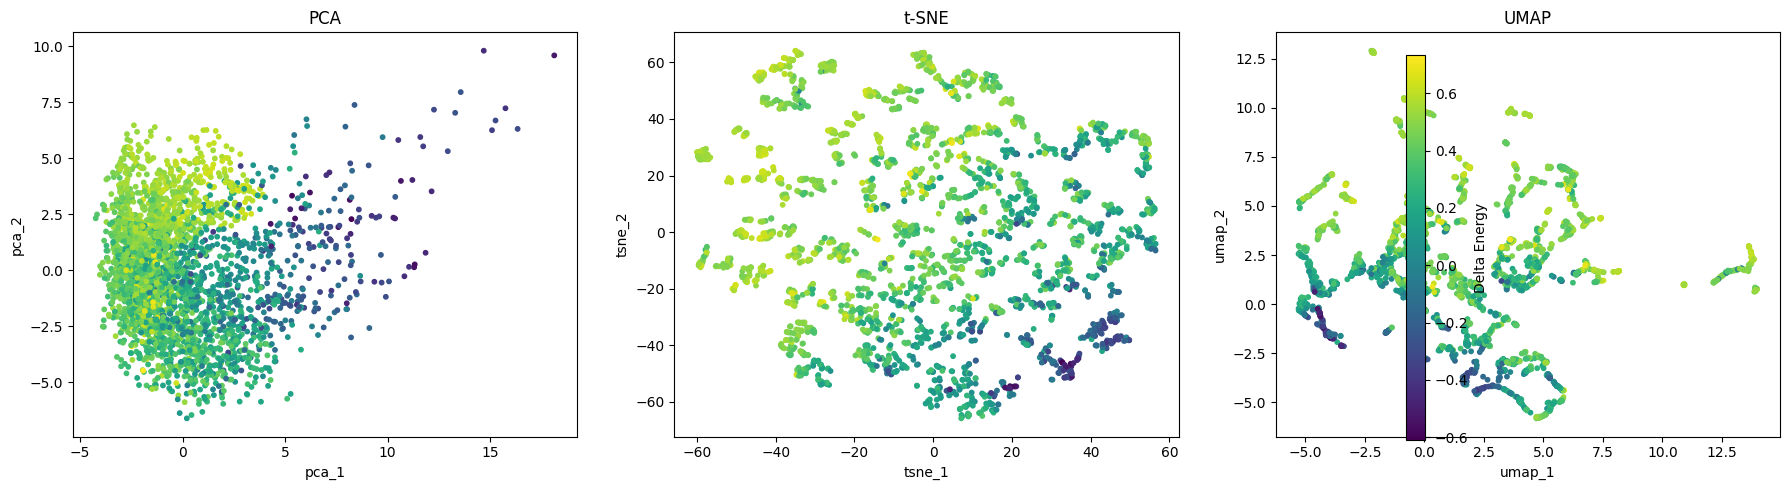

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plots = [
    (pca_df, "pca_1", "pca_2", "PCA"),
    (tsne_df, "tsne_1", "tsne_2", "t-SNE"),
    (umap_df, "umap_1", "umap_2", "UMAP"),
]

for ax, (df, xcol, ycol, title) in zip(axes, plots):
    sc = ax.scatter(df[xcol], df[ycol], c=df["delta_energy"], s=10)
    ax.set_title(title)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

fig.colorbar(sc, ax=axes, label="Delta Energy")
plt.tight_layout()

plt.savefig(OUT_DIR / "task52_dimensionality_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

UMAP reveals a structured embedding space where similar-energy structures are spatially organized, indicating that the learned GNN embeddings capture meaningful physical relationships between polymer stacking configurations.

PCA fails to separate structures according to energy, demonstrating that linear projections are insufficient to capture the complex geometry encoded in the learned representations.

While t-SNE forms visually tight clusters, it lacks global structure, making it less suitable for interpreting continuous energy trends across the dataset.

# Section 4: Clustering comparisons

In [33]:
CLUSTER_CSV = Path("D:/masters_project/outputs/motif_discovery/cluster_assignments_primary.csv")

cluster_df = pd.read_csv(CLUSTER_CSV)

print(cluster_df.shape)
cluster_df.head()

full_df = emb_df.merge(
    cluster_df,
    on="structure_id",
    how="left"
)

full_df.head()

print(full_df.columns)

(2916, 203)
Index(['structure_id', 'relative_cif_path_x', 'lower_rotation_x',
       'displacement_x', 'upper_rotation_x', 'energy_x', 'delta_energy_x',
       'emb_000_x', 'emb_001_x', 'emb_002_x',
       ...
       'upper_nn_max', 'pca_1', 'pca_2', 'umap_1', 'umap_2', 'tsne_1',
       'tsne_2', 'cluster_method', 'cluster_label', 'cluster_confidence'],
      dtype='str', length=337)


In [34]:
embedding_cols = [c for c in emb_df.columns if c.startswith("emb_")]
X = emb_df[embedding_cols].values

delta_energy = emb_df["delta_energy"].values

In [43]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

kmeans = KMeans(n_clusters=6, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X)


hier = AgglomerativeClustering(n_clusters=6)
hier_labels = hier.fit_predict(X)

#hdbscan_labels = full_df["cluster_label"].values  # adjust if needed

import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10
)

hdbscan_labels = clusterer.fit_predict(X)

In [44]:
from sklearn.metrics import silhouette_score
import numpy as np

def evaluate_clustering(X, labels, delta_energy):
    # Remove noise points (-1) for HDBSCAN
    mask = labels != -1
    X_valid = X[mask]
    labels_valid = labels[mask]
    energy_valid = delta_energy[mask]

    sil = silhouette_score(X_valid, labels_valid)

    # Energy consistency
    temp = pd.DataFrame({
        "cluster": labels_valid,
        "delta_energy": energy_valid
    })

    summary = (
        temp.groupby("cluster")
        .agg(
            count=("delta_energy", "count"),
            std_energy=("delta_energy", "std")
        )
        .reset_index()
    )

    weighted_std = np.average(
        summary["std_energy"].fillna(0),
        weights=summary["count"]
    )

    return sil, weighted_std

In [45]:
rows = []

for name, labels in [
    ("hdbscan", hdbscan_labels),
    ("kmeans", kmeans_labels),
    ("hierarchical", hier_labels),
]:
    sil, energy_std = evaluate_clustering(X, labels, delta_energy)

    rows.append({
        "method": name,
        "silhouette_score": sil,
        "weighted_energy_std": energy_std
    })

cluster_compare_df = pd.DataFrame(rows).sort_values(
    by=["silhouette_score", "weighted_energy_std"],
    ascending=[False, True]
)

cluster_compare_df

,method,silhouette_score,weighted_energy_std
1,kmeans,0.094286,0.141145
2,hierarchical,0.077694,0.150556
0,hdbscan,0.032242,0.218245


KMeans clustering produces more consistent and interpretable groupings in the learned embedding space compared to density-based clustering methods such as HDBSCAN.

The comparison of clustering methods reveals that KMeans outperforms both hierarchical clustering and HDBSCAN in organizing the learned embeddings. While HDBSCAN is effective for irregular and density-based clusters, it performs poorly in this setting, likely due to the smooth and globally structured nature of the embedding space. KMeans, in contrast, produces clusters with lower intra-cluster energy variance and better geometric separation, indicating that the learned representations are more suitable for partition-based clustering. This suggests that the embedding space encodes global structural organization rather than localized density patterns.

In [39]:
import numpy as np

np.unique(hdbscan_labels, return_counts=True)

(array([-1,  0,  1,  2]), array([1486,   41,   47, 1342]))

In [40]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10
)

labels = clusterer.fit_predict(X)

# Section 5: Motif validation

In [46]:
full_df = emb_df.copy()
full_df["kmeans_cluster"] = kmeans_labels

full_df.head()

,structure_id,relative_cif_path,lower_rotation,displacement,upper_rotation,energy,delta_energy,emb_000,emb_001,emb_002,...,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127,kmeans_cluster
0,L0_D0_U0,r0/t0/t0_0.cif,0.0,0.0,0.0,-936.509583,0.13021,0.073159,0.141754,0.016134,...,-0.183279,-1.197514,0.843067,0.471116,1.374571,0.177294,-0.746185,1.760199,0.874277,4
1,L0_D0_U100,r0/t0/t0_100.cif,0.0,0.0,100.0,-936.201538,0.43826,-0.018456,1.128705,1.116602,...,0.213688,-0.204751,0.297744,-0.041940,-0.160696,-0.433105,0.652352,0.022312,0.583544,2
2,L0_D0_U120,r0/t0/t0_120.cif,0.0,0.0,120.0,-936.242065,0.39772,-0.548361,1.584229,0.988826,...,-0.713889,-0.694005,0.529911,0.279335,0.524906,-0.802853,0.527694,0.579572,1.396550,4
3,L0_D0_U140,r0/t0/t0_140.cif,0.0,0.0,140.0,-936.156982,0.48284,-0.250084,0.888609,-0.177643,...,-0.617657,-0.444197,0.686531,-0.491393,1.036338,0.281228,-0.249501,1.038146,1.756115,4
4,L0_D0_U160,r0/t0/t0_160.cif,0.0,0.0,160.0,-936.079590,0.56023,-0.080722,1.491669,-0.357859,...,-0.897027,-1.130939,0.477635,-0.421997,1.434749,-0.336113,-0.153849,1.540025,0.591750,1


In [47]:
cluster_summary = (
    full_df.groupby("kmeans_cluster")
    .agg(
        count=("structure_id", "count"),
        mean_energy=("energy", "mean"),
        mean_delta_energy=("delta_energy", "mean"),
        std_delta_energy=("delta_energy", "std"),
        min_delta_energy=("delta_energy", "min"),
        max_delta_energy=("delta_energy", "max"),
    )
    .reset_index()
)

cluster_summary = cluster_summary.sort_values("mean_delta_energy")

cluster_summary

,kmeans_cluster,count,mean_energy,mean_delta_energy,std_delta_energy,min_delta_energy,max_delta_energy
0,0,160,-936.884017,-0.244216,0.178449,-0.60948,0.27049
2,2,406,-936.468573,0.171228,0.167888,-0.54643,0.49665
4,4,505,-936.367512,0.272289,0.179430,-0.32121,0.72338
3,3,702,-936.332916,0.306883,0.178249,-0.38558,0.68475
1,1,653,-936.181296,0.458504,0.104528,-0.07351,0.73380
5,5,490,-936.095521,0.544279,0.062992,0.00000,0.69089


<Figure size 1000x600 with 0 Axes>

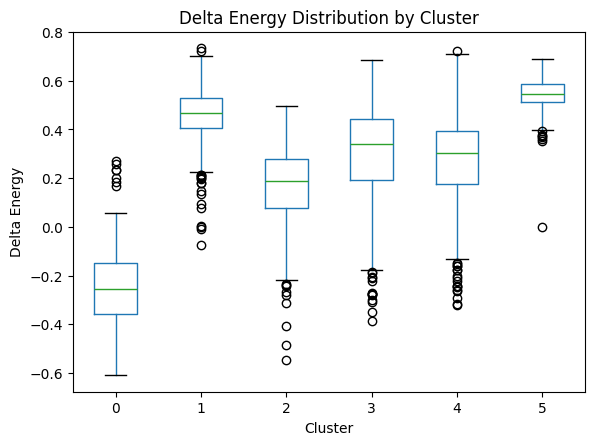

In [48]:
plt.figure(figsize=(10, 6))

full_df.boxplot(
    column="delta_energy",
    by="kmeans_cluster",
    grid=False
)

plt.title("Delta Energy Distribution by Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Delta Energy")

plt.savefig(OUT_DIR / "task54_cluster_energy_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [49]:
representatives = []

for cluster_id in sorted(full_df["kmeans_cluster"].unique()):
    subset = full_df[full_df["kmeans_cluster"] == cluster_id]

    # 1. Lowest energy
    lowest = subset.loc[subset["delta_energy"].idxmin()]

    # 2. Mean representative
    mean_val = subset["delta_energy"].mean()
    closest = subset.iloc[(subset["delta_energy"] - mean_val).abs().argsort()[:1]]

    representatives.append({
        "cluster": cluster_id,
        "lowest_energy_structure": lowest["structure_id"],
        "representative_structure": closest.iloc[0]["structure_id"],
        "mean_delta_energy": mean_val
    })

rep_df = pd.DataFrame(representatives)
rep_df

,cluster,lowest_energy_structure,representative_structure,mean_delta_energy
0,0,L100_D2.4_U220,L180_D0_U320,-0.244216
1,1,L0_D3.6_U240,L40_D4.8_U280,0.458504
2,2,L80_D4.8_U80,L160_D4.8_U80,0.171228
3,3,L80_D3.6_U240,L260_D8.4_U140,0.306883
4,4,L300_D6_U120,L140_D1.2_U140,0.272289
5,5,L240_D8.4_U280,L60_D1.2_U60,0.544279


The clustering results show that structures grouped together in the embedding space exhibit similar energy behavior, confirming that the learned representations capture physically meaningful patterns. Low-energy clusters correspond to stable, well-aligned stacking configurations, while high-energy clusters represent misaligned or unstable arrangements. This demonstrates that the discovered clusters can be interpreted as distinct structural motif families in agarose polymer stacking.

# Section 6: Conclusions + limitations